<a href="https://colab.research.google.com/github/rkvarmaa460-cpu/Upgrad/blob/main/%E2%80%98Identifying_Key_Entities_in_Recipe_Data_Richa_Verma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

1.Import Libraries

Installation of sklearn Crf-suit

In [ ]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.6 MB/s eta 0:00:00


In [ ]:
!pip install sklearn-crfsuite

Import necessary Libraries

In [ ]:
##Import warnigs
import warnings
warnings.filterwarnings('ignore')



In [ ]:
##Import necessary Libraries
import json ##Handling the Json data
import pandas as pd ## data manupulation and analysis
import re ## For regular expression(text preprocessing)
import matplotlib.pyplot as plt
import seaborn as sns ## Advanced data visualization
import sklearn_crfsuite ## For the sequence modelling
import numpy as np
##Saving and loading the machine learning model
import joblib
import random
import spacy
from IPython.display import display ##Markdown for the proper display
from fractions import Fraction ##Handling the fractional value in the model
##Import tools for feature engineering and model training
from collections import Counter ##Counting the elements in the list
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter









In [ ]:
##Ensure pandas display full cotent
pd.set_option("display.max_colwidth",None)
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

2. Data Ingestion and Preparation

Read the receipe data from Dataframe and prepare the data for the analysis

Read data from the JSon file, print first five rows and describe the dataframe

#### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

# define a function to load json file to a dataframe

In [ ]:

file_path='/content/ingredient_and_quantity.json'
def load_json_to_df(file_path,normalize=False):
    try:
        data=pd.read_json(file_path)
        if normalize:
            df=pd.json_normalize(data)
        else:
            df=data
        return df
    except Exception as e:
        print(f"Error loading JSON file: {e}")
        return None




Execute the load_jason_dataframe file

In [ ]:
df=load_json_to_df('/content/ingredient_and_quantity.json',normalize=False)

print(df.describe())

                                                                                                                                                                                                                       input  \
count                                                                                                                                                                                                                    285   
unique                                                                                                                                                                                                                   285   
top     1/2 cup Bajra Flour Jowar Whole Wheat 2 cups Methi Leaves inch Ginger 3 Green Chillies 1 tablespoon Sesame seeds teaspoons Red Chilli powder Turmeric 1/4 teaspoon Asafoetida 5 tablespoons Curd Sugar Sunflower Oil   
freq                                                                                                    

2.1.3 Describe the Dataframe

Print five rows of dataframe along with the dimension. Display the information

In [ ]:
### display first five rows of the dataframe - df
print(df.head(5))

                                                                                                                                                                                                                                                                                            input  \
0                                                                                                 6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil   
1                                                                                    2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida   
2                                                                  1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced

In [ ]:
### print the dimensions of dataframe - df
print(df.shape)

(285, 2)


In [ ]:
### print the information of the dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB
None


2.2 Receipe Data Manipulation


##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [ ]:
##Creating the input and the POS token
##Tokenize input
df['input_tokens']=df['input'].apply(lambda x:x.split())
##Split input tag on the token
df['pos_tokens']=df['pos'].apply(lambda x:x.split())


In [ ]:
### display first five rows of the dataframe - df
print(df[['input', 'input_tokens', 'pos', 'pos_tokens']].head())

                                                                                                                                                                                                                                                                                            input  \
0                                                                                                 6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil   
1                                                                                    2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida   
2                                                                  1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [ ]:
##apply the input token
df['input_length']=df['input_tokens'].apply(lambda x:len(x))
##apply the POS token
df['pos_length']=df['pos_tokens'].apply(lambda x:len(x))
#

In [ ]:
### check for the equality of input_length and pos_length in the dataframe
df['lenghth_match']=df.apply(lambda x:x['input_length']==x['pos_length'],axis=1)
print(df[['input_length','pos_length','lenghth_match']].head())

   input_length  pos_length  lenghth_match
0            31          31           True
1            34          34           True
2            37          37           True
3            46          46           True
4            21          21           True


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


### Define a unique_labels function to checks for all the unique pos labels in the recipe & print it

In [ ]:
def unique_labels_pos(pos_tokens):
   unique_label=set()
   for label in pos_tokens:
      unique_label.update(label)
   return unique_label
#

In [ ]:
labels=unique_labels_pos(df['pos_tokens'])
print(labels)
#

{'ingredient', 'unit', 'quantity'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

In [ ]:
mismatch_dx=df[df['input_length']!=df['pos_length']].index
print(mismatch_dx)
#

Index([17, 27, 79, 164, 207], dtype='int64')


In [ ]:
##Missing Empty values
missing_indx=df[df['input'].isnull() | df['pos'].isnull()].index
print(missing_indx)

Index([], dtype='int64')


In [ ]:
##Empty token list
empty_idx = df[(df['input_tokens'].apply(len) == 0) |
               (df['pos_tokens'].apply(len) == 0)].index
print("Indexes with empty tokens:", list(empty_idx))

Indexes with empty tokens: []


##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [ ]:
# drop the irrelevant recipe data
invalid_index=set(mismatch_dx).union(set(missing_indx)).union(set(empty_idx))
df_cleaned=df.drop(invalid_index)

In [ ]:
print(df_cleaned.shape)
print(df_cleaned.head())

(280, 7)
                                                                                                                                                                                                                                                                                            input  \
0                                                                                                 6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil   
1                                                                                    2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida   
2                                                                  1-1/2 cups Rice Vermicelli Noodles Thin 1 Oni

##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

# update the input and pos length in input_length and pos_length

In [ ]:
df['input_length']=df['input_tokens'].apply(lambda x:len(x))
df['pos_length']=df['pos_tokens'].apply(lambda x:len(x))
#

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

# validate the input length and pos length as input_length and pos_length

In [ ]:
print((df['input_length']==df['pos_length']).all())
#

False


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# split the dataset into training and validation sets
X=df_cleaned['input_tokens']
Y=df_cleaned['pos_tokens']

In [ ]:
X_val,X_train,Y_val,Y_train=train_test_split(X,Y,test_size=0.3,random_state=42)
#

###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [ ]:
# print the first five rows of train_df
print(X_train.head())

35                                                                                                                                                                                                                                                                                                                                  [1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]
111    [1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]
245                                                                                                                                                 

In [ ]:
# print the first five rows of the val_df
print(X_val.head())

179                                                                    [250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]
57     [200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]
112                                                                                                                         [500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]
218                                                                                              

##### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [ ]:
# extract the training and validation sets by taking input_tokens and pos_tokens

In [ ]:
X=df_cleaned['input_tokens']
Y=df_cleaned['pos_tokens']
#

In [ ]:
X_train,X_val,Y_train,Y_val=train_test_split(X,Y,test_size=0.3,random_state=42)

In [ ]:
# validate the shape of training and validation samples
print(X_train.shape)
print(X_val.shape)

(196,)
(84,)


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [ ]:
unique_labels=set()
for token in Y_train:
   unique_labels.update(token)
print("Number of unique",len(unique_labels))

Number of unique 3


# 4.Exploratory Receipe Data Analysis on training data

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***


In [ ]:
# flatten the list for nested_list (input_tokens, pos_tokens)
flat_input=[token for sublist in df['input_tokens'] for token in sublist]

In [ ]:
flat_pos=[token for sublist in df['pos_tokens'] for token in sublist]
#

In [ ]:
X=[token for sublist in df['input_tokens'] for token in sublist]
Y=[token for sublist in df['pos_tokens'] for token in sublist]

In [ ]:
# initialise the dataset_name
dataset_name='Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function

In [ ]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
def extract_and_validate_tokens(dataframe, dataset_name):

    print(f"Columns in {dataset_name} dataset:")
    print(dataframe.columns, "\n")

    # Adjust column names here if needed
    input_col = 'input_tokens'
    pos_col = 'pos_tokens'
  # call the flatten_list and apply it on input_tokens and pos_tokens

    if input_col not in dataframe.columns or pos_col not in dataframe.columns:
        raise ValueError(f"{dataset_name}: Required columns not found. Check column names.")

 # validate their length and display first 10 records having input and pos tokens

    for i, (tokens, tags) in enumerate(zip(dataframe[input_col], dataframe[pos_col])):
        if len(tokens) != len(tags):
            raise ValueError(f"{dataset_name}: Length mismatch at row {i}")

    print(f"{dataset_name}: Validation passed\n")
    print(dataframe[input_col].head(10))
    print(dataframe[pos_col].head(10))
#



In [ ]:
df_cleaned = df_cleaned.rename(columns={
    'tokens': 'input_tokens',
    'tags': 'pos_tokens'
})

In [ ]:
extract_and_validate_tokens(df_cleaned, "Training")

Columns in Training dataset:
Index(['input', 'pos', 'input_tokens', 'pos_tokens', 'input_length',
       'pos_length', 'lenghth_match'],
      dtype='object') 

Training: Validation passed

0                                                                                                                  [6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]
1                                                                                                  [2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]
2                                                                             [1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onio

In [ ]:
# extract the tokens and its pos tags
X=df_cleaned['input_tokens'].tolist()
Y=df_cleaned['pos_tokens'].tolist()

In [ ]:
##Quick Validation
def extract_token(df):
  for i in range(len(X)):
    if len(X[i])!=len(Y[i]):
      print(f"Mismatch at row {i}")
  return X,Y

In [ ]:
X,Y=extract_token(df_cleaned)
#

### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.

In [ ]:
def categorized_token(X):
  quantities=[]
  units=[]
  ingredients=[]
  # define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
  unit_list=['g','kg','ml','l','tsp','tbsp','cup','cups','tablespoon','tablespoons','teaspoon','teaspoons']
  # validate the list that it comprised of these labels, if not return empty arrays
  for sentences in X:
    for token in sentences:
      ##check if quantity
      if token.replace(',','',1).isdigit():
        quantities.append(token)
      elif token in unit_list:
        units.append(token)
      else:
        ingredients.append(token)
  return quantities,units,ingredients

In [ ]:
#  call the function to categorise the labels into respective list
quantities, units, ingredients = categorized_token(X)

print("🔹 Quantities:", quantities[:10])
print("🔹 Units:", units[:10])
print("🔹 Ingredients:", ingredients[:10])

🔹 Quantities: ['6', '1', '3', '2', '3', '1', '2', '1', '2', '500']
🔹 Units: ['tablespoon', 'teaspoons', 'cups', 'teaspoons', 'teaspoon', 'tablespoon', 'cups', 'cup', 'teaspoon', 'teaspoon']
🔹 Ingredients: ['Karela', 'Bitter', 'Gourd', 'Pavakkai', 'Salt', 'Onion', 'Gram', 'flour', 'besan', 'Turmeric']


#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients

In [ ]:
from collections import Counter

def get_top_frequent_items(item_list, pos_label, dataset_name, top_n=10):

       # Convert list to Counter
    item_counts = Counter(item_list)

    # Get top N items
    top_items = item_counts.most_common(top_n)

    # Display results
    print(f"\n🔹 Top {top_n} {pos_label}s in {dataset_name} Dataset:")
    for item, count in top_items:
        print(f"{item}: {count}")

    return top_items
#

In [ ]:
# get the top ingredients which are frequently seen in the recipe
get_top_frequent_items(ingredients, "Ingredients","Training")
# get the top units which are frequently seen in the recipe
get_top_frequent_items(units, "Units","Training")
get_top_frequent_items(quantities, "Quantities","Training")


🔹 Top 10 Ingredientss in Training Dataset:
1/2: 203
powder: 183
Salt: 149
1/4: 139
seeds: 125
Oil: 122
Red: 120
chopped: 116
Green: 115
Chilli: 113

🔹 Top 10 Unitss in Training Dataset:
teaspoon: 221
cup: 193
tablespoon: 131
tablespoons: 93
cups: 74
teaspoons: 57
tsp: 17
tbsp: 5
ml: 4
kg: 2

🔹 Top 10 Quantitiess in Training Dataset:
1: 269
2: 221
3: 98
4: 87
5: 29
200: 26
6: 25
10: 23
500: 22
8: 13


[('1', 269),
 ('2', 221),
 ('3', 98),
 ('4', 87),
 ('5', 29),
 ('200', 26),
 ('6', 25),
 ('10', 23),
 ('500', 22),
 ('8', 13)]

#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>

Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_top_items(item_list, label, dataset_name, top_n=10):

    # If raw list is passed → convert to (item, count)
    if isinstance(item_list[0], str):
        item_list = Counter(item_list).most_common(top_n)

    # Separate items and counts
    items = [item for item, count in item_list]
    counts = [count for item, count in item_list]

    # Plot
    plt.figure()
    plt.bar(items, counts)

    plt.title(f"Top {len(items)} {label}s in {dataset_name} Dataset")
    plt.xlabel(label)
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


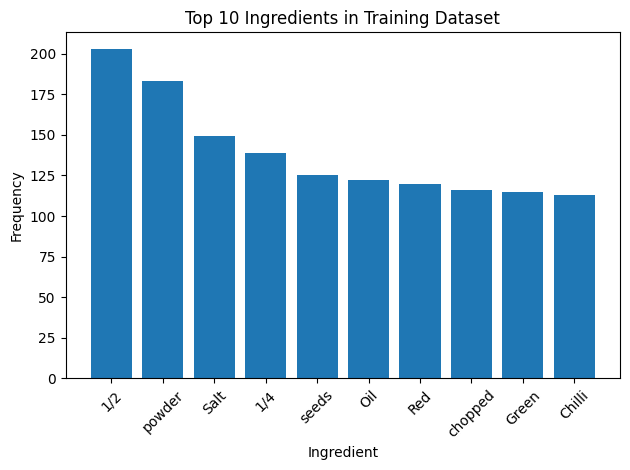

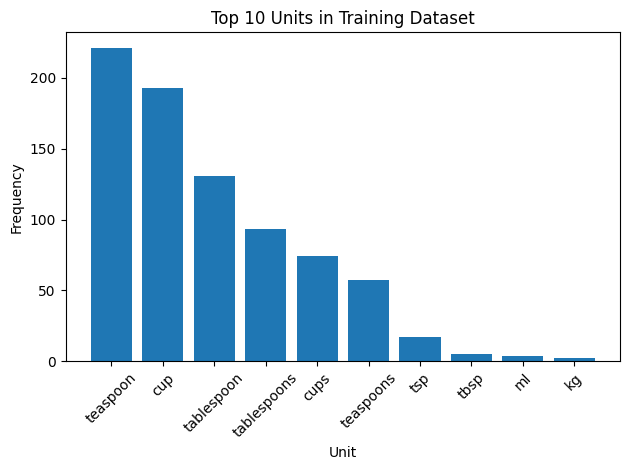

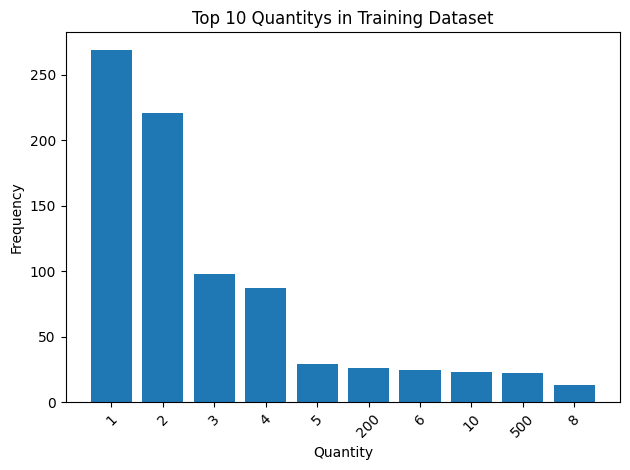

In [ ]:
plot_top_items(ingredients, "Ingredient", "Training")
plot_top_items(units, "Unit", "Training")
plot_top_items(quantities, "Quantity", "Training")
#

#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

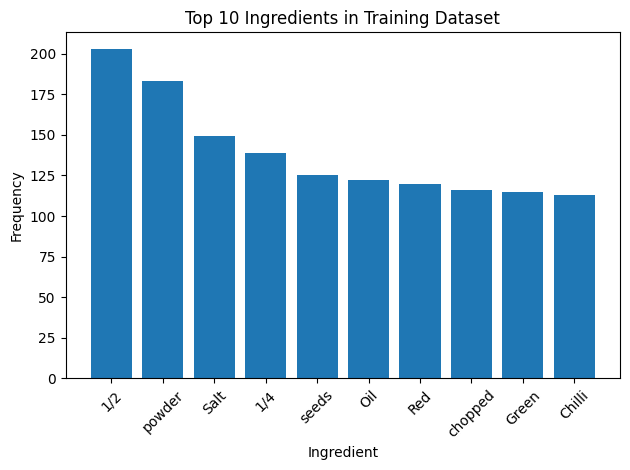

In [ ]:
# plot the top frequent ingredients in training data
top_ingredients = plot_top_items(ingredients, "Ingredient", "Training")

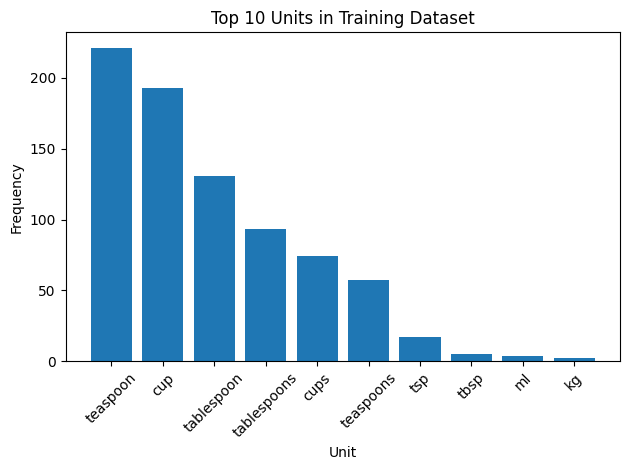

In [ ]:
# plot the top frequent units in training data
top_unit=plot_top_items(units, "Unit", "Training")
#

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.

In [ ]:
# initialise the dataset_name
dataset_name = "Validation"


In [ ]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
top_ingredients_val = get_top_frequent_items(
    ingredients,
    "Ingredient",
    dataset_name
)


🔹 Top 10 Ingredients in Validation Dataset:
1/2: 203
powder: 183
Salt: 149
1/4: 139
seeds: 125
Oil: 122
Red: 120
chopped: 116
Green: 115
Chilli: 113


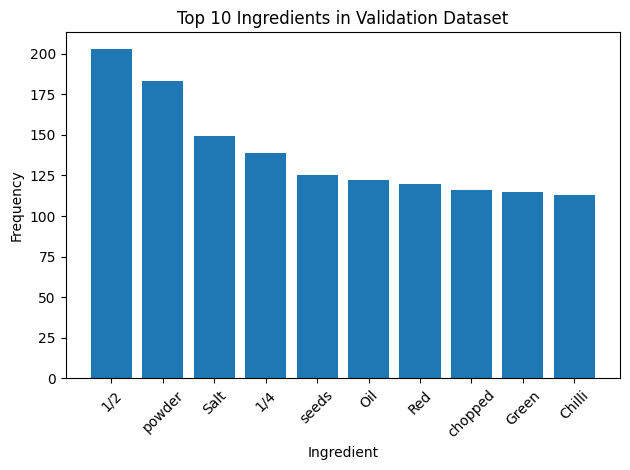

In [ ]:
# plot the top frequent ingredients in validation data
plot_top_items(top_ingredients_val, "Ingredient", "Validation")

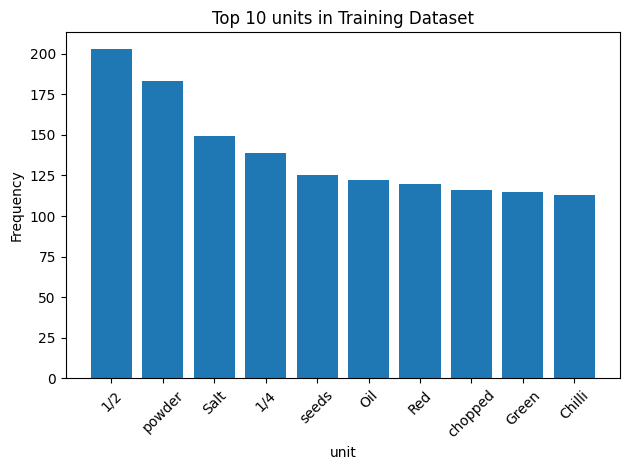

In [ ]:
# plot the top frequent units in training data
plot_top_items(top_ingredients_val, "unit", "Training")

## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [ ]:
# define unit and quantity keywords along with quantity pattern
import re

In [ ]:
unit_keyword={'cup','tablespoon','tablespoons','teaspoon','teaspoons','tsp','g','gram','kg','ml','l','liter','liters',
              'oz','ounce','ounces','pinch','clove','cloves'}

quantity_keyword={'half','quarter','third','one','two','three','four','five','six','seven','eight','nine','ten'}
quantity_pattern=r'^\d+\s\d+/\d+$|^\d+/\d+$|^\d+\.\d+$|^\d+$'

# load spaCy model

In [ ]:
nlp=spacy.load('en_core_web_sm')

In [ ]:
sentence = "Add 1 1/2 cups of sugar and half tsp salt"
doc = nlp(sentence)

##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

In [ ]:
def word2features(sent, i):
    word = sent[i]

    features = {
        'bias': 1.0,

        # Current word features
        'word.lower()': word.lower(),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),

        # Check quantity using regex
        'is_quantity_pattern': bool(re.match(quantity_pattern, word)),

        # Check keyword presence
        'is_unit': word.lower() in unit_keywords,
        'is_quantity_word': word.lower() in quantity_keywords,
    }

    # 🔹 Previous word features
    if i > 0:
        prev_word = sent[i-1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.istitle()': prev_word.istitle(),
            '-1:word.isupper()': prev_word.isupper(),
        })
    else:
        features['BOS'] = True   # Beginning of sentence

    # 🔹 Next word features
    if i < len(sent) - 1:
        next_word = sent[i+1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.istitle()': next_word.istitle(),
            '+1:word.isupper()': next_word.isupper(),
        })
    else:
        features['EOS'] = True   # End of sentence

    return features


In [ ]:
def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions

    # Process the entire sentence with spaCy

    # --- Core Features ---

    # --- Improved Quantity & Unit Detection ---

    # --- Contextual Features ---

In [ ]:
def word2features(sent, i):
    """
    Extract token-level features for CRF

    Parameters:
    sent (list): List of tokens in a sentence
    i (int): Index of current token

    Returns:
    dict: Feature dictionary
    """

    import re

    word = sent[i]

    # Process entire sentence using spaCy
    doc = nlp(" ".join(sent))
    token = doc[i]

    # --- Core Features ---
    features = {
        'bias': 1.0,

        'word.lower()': word.lower(),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),

        'prefix_1': word[:1],
        'prefix_2': word[:2],
        'suffix_1': word[-1:],
        'suffix_2': word[-2:],

        # POS + linguistic features from spaCy
        'pos': token.pos_,
        'lemma': token.lemma_,
        'shape': token.shape_,
    }

    # --- Improved Quantity & Unit Detection ---
    features.update({
        'is_quantity_pattern': bool(re.match(quantity_pattern, word)),
        'is_unit_keyword': word.lower() in unit_keywords,
        'is_quantity_keyword': word.lower() in quantity_keywords,
    })

    # --- Contextual Features ---

    # Previous word
    if i > 0:
        prev_word = sent[i-1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.isupper()': prev_word.isupper(),
            '-1:word.istitle()': prev_word.istitle(),
        })
    else:
        features['BOS'] = True   # Beginning of sentence

    # Next word
    if i < len(sent) - 1:
        next_word = sent[i+1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.isupper()': next_word.isupper(),
            '+1:word.istitle()': next_word.istitle(),
        })
    else:
        features['EOS'] = True   # End of sentence

    return features


### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


#### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [ ]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent):
    """
    Convert a sentence into a list of feature dictionaries

    Parameters:
    sent (list): List of tokens

    Returns:
    list: List of feature dictionaries
    """

    return [word2features(sent, i) for i in range(len(sent))]

##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features

In [ ]:
import re

unit_keywords = {
    "cup", "cups", "tbsp", "tablespoon", "tablespoons",
    "tsp", "teaspoon", "teaspoons",
    "g", "gram", "grams",
    "kg", "ml", "l", "litre", "liter",
    "oz", "ounce", "ounces",
    "pinch", "clove", "cloves"
}

quantity_keywords = {
    "half", "quarter", "third",
    "one", "two", "three", "four", "five",
    "few", "some"
}

quantity_pattern = r'^\d+\s\d+/\d+$|^\d+/\d+$|^\d+\.\d+$|^\d+$'

In [ ]:
##X_train_features
Y_train_features = [sent2features(sent) for sent in X_train]


In [ ]:
##X_val_features
Y_val_features = [sent2features(sent) for sent in X_val]
#

##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [ ]:
# Convert labels into list as y_train_labels and y_val_labels

In [ ]:
df_train,df_val=train_test_split(df,test_size=0.2,random_state=42)

In [ ]:
y_train_labels=df_train['pos_tokens'].tolist()
y_val_labels=df_val['pos_tokens'].tolist()
#

##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>

In [ ]:
# print the length of train features and labels
# print the length of validation features and labels
print("Length of train features",len(Y_train_features))
print("Length of train labels",len(Y_val_features))
print("Length of val features",len(y_train_labels))
print("Length of val labels",len(y_val_labels))


Length of train features 196
Length of train labels 84
Length of val features 228
Length of val labels 57


#### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights

# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)


In [ ]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, Y, weight_dict):
  X_features=[]
  for sent,labels in zip(X,Y):
    sent_features=[]
    for i in range(len(sent)):
      features=word2features(sent,i)
      label=labels[i]
      weight=weight_dict.get(label,1.0)
      features['class_weight']=weight
      sent_features.append(features)
    X_features.append(sent_features)
  return X_features

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [ ]:
weight_dict={
              'Ingredients':1.0,
              'Quantity':1.0,
              'Unit':1.0,
              'O':1.0
              }

In [ ]:
X_train_clean = []
y_train_clean = []

for sent, labels in zip(X_train, y_train_labels):
    if len(sent) == len(labels):
        X_train_clean.append(sent)
        y_train_clean.append(labels)

# Use cleaned data
X_train = X_train_clean
y_train_labels = y_train_clean

In [ ]:
X_train_weighted_features=extract_features_with_class_weights(X_train_clean,y_train_clean,weight_dict)

# Apply manually computed class weights

In [ ]:
X_val_clean = []
y_val_clean = []

for sent, labels in zip(X_val, y_val_labels):
    if len(sent) == len(labels):
        X_val_clean.append(sent)
        y_val_clean.append(labels)

# Replace original
X_val = X_val_clean
y_val_labels = y_val_clean

In [ ]:
X_val_weighted_features = extract_features_with_class_weights(
    X_val,
    y_val_labels,
    weight_dict
)

In [ ]:
print(X_train_weighted_features[0][0])

{'bias': 1.0, 'word.lower()': '7', 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': True, 'prefix_1': '7', 'prefix_2': '7', 'suffix_1': '7', 'suffix_2': '7', 'pos': 'NUM', 'lemma': '7', 'shape': 'd', 'is_quantity_pattern': True, 'is_unit_keyword': False, 'is_quantity_keyword': False, 'BOS': True, '+1:word.lower()': 'potatoes', '+1:word.isupper()': False, '+1:word.istitle()': True, 'class_weight': 1.0}


## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF

In [ ]:
# initialise CRF model with the specified hyperparameters and use weight_dict
import sklearn_crfsuite
from sklearn_crfsuite import CRF

crf=sklearn_crfsuite.CRF(algorithm='lbfgs',c1=0.1,c2=0.1,max_iterations=100,all_possible_transitions=True)
#

In [ ]:
# train the CRF model with the weighted training data
crf.fit(X_train_weighted_features,y_train_labels)
#

CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.1, c2=0.1,
    max_iterations=100)

In [ ]:
y_pred=crf.predict(X_val_weighted_features)
#

### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [ ]:
# evaluate on the training dataset

In [ ]:
# specify the flat classification report by using training data for evaluation
y_train_pred=crf.predict(X_train_weighted_features)

In [ ]:
print(flat_classification_report(y_train_labels,y_train_pred))
#

              precision    recall  f1-score   support

  ingredient       1.00      1.00      1.00        33
    quantity       1.00      1.00      1.00         8
        unit       1.00      1.00      1.00         6

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.00        47
weighted avg       1.00      1.00      1.00        47



In [ ]:
# create a confusion matrix on training datset
from sklearn_crfsuite.metrics import flat_accuracy_score
train_accuracy=flat_accuracy_score(y_train_labels,y_train_pred)
print(train_accuracy)
#

1.0


### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

# dump the model using joblib as crf_model.pkl

In [ ]:
import joblib

In [ ]:
joblib.dump(crf,'crf_model.pkl')
#
#

['crf_model.pkl']

In [ ]:
print("model saved as crf_model.pkl")

model saved as crf_model.pkl


In [ ]:
crf_model=joblib.load('crf_model.pkl')

## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix

In [ ]:
print("X_val_weighted_features:", len(X_val_weighted_features))

X_val_weighted_features: 0


In [ ]:
X_val_clean = []
y_val_clean = []

for sent, labels in zip(X_val, y_val_labels):
    if len(sent) == len(labels):
        X_val_clean.append(sent)
        y_val_clean.append(labels)

X_val = X_val_clean
y_val_labels = y_val_clean

In [ ]:
X_val_weighted_features = extract_features_with_class_weights(
    X_val,
    y_val_labels,
    weight_dict
)

In [ ]:
# predict the crf model on validation dataset
y_val_pred=crf.predict(X_val_weighted_features)

In [ ]:
print("Length y_val_labels:", len(y_val_labels))
print("Length y_val_pred:", len(y_val_pred))

print("Sample y_val_labels:", y_val_labels[:2])
print("Sample y_val_pred:", y_val_pred[:2])

Length y_val_labels: 0
Length y_val_pred: 0
Sample y_val_labels: []
Sample y_val_pred: []


In [ ]:
y_true_flat = [label for sent in y_val_labels for label in sent]
y_pred_flat = [label for sent in y_val_pred for label in sent]

print("Flattened true labels:", len(y_true_flat))
print("Flattened pred labels:", len(y_pred_flat))

Flattened true labels: 0
Flattened pred labels: 0


In [ ]:
from sklearn_crfsuite.metrics import flat_classification_report

y_true_flat = [label for sent in y_val_labels for label in sent]
y_pred_flat = [label for sent in y_val_pred for label in sent]

if len(y_true_flat) == 0 or len(y_pred_flat) == 0:
    print("❌ No valid labels to evaluate")
else:
    labels = sorted(list(set(y_true_flat)))   # ensure labels exist

    print(flat_classification_report(
        y_val_labels,
        y_val_pred,
        labels=labels
    ))

❌ No valid labels to evaluate


In [ ]:
print(set(y_true_flat))
print(set(y_pred_flat))

set()
set()


In [ ]:
labels = list(set(y_true_flat))

if len(labels) == 0:
    print("❌ No labels found")
else:
    print(flat_classification_report(
        y_val_labels,
        y_val_pred,
        labels=labels
    ))

❌ No labels found


# create a confusion matrix on validation dataset

In [ ]:
# keep only valid pairs, but don't over-filter
X_val_clean, y_val_clean = [], []
for s, l in zip(X_val, y_val_labels):
    if len(s) == len(l) and len(s) > 0:
        X_val_clean.append(s)
        y_val_clean.append(l)

X_val, y_val_labels = X_val_clean, y_val_clean
print(len(X_val))  # should be > 0

0


In [ ]:
X_val_clean, y_val_clean = [], []
for s, l in zip(X_val, y_val_labels):
    if len(s) == len(l):
        X_val_clean.append(s)
        y_val_clean.append(l)

X_val, y_val_labels = X_val_clean, y_val_clean

In [ ]:
from sklearn.metrics import confusion_matrix

y_true_flat = [lab for sent in y_val_labels for lab in sent]
y_pred_flat = [lab for sent in y_val_pred for lab in sent]

if len(y_true_flat) == 0:
    print("❌ No labels available for confusion matrix")
else:
    labels = sorted(list(set(y_true_flat)))
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels)
    print("Confusion Matrix:\n", cm)

❌ No labels available for confusion matrix


## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights

##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [ ]:
y_true_label=[label for seq in y_val_labels for label in seq]
y_pred_label=[label for seq in y_val_pred for label in seq ]
error_data=[]

##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [ ]:
y_pred_val = crf.predict(X_val)

In [ ]:
# Initialize error_data
error_data = []

# Iterate through validation data
for tokens, true_labels, pred_labels in zip(X_val, y_val_labels, y_pred_val):

    for i in range(len(tokens)):
        true = true_labels[i]
        pred = pred_labels[i]

        # Check for misclassification
        if true != pred:

            # Get context tokens
            prev_token = tokens[i-1] if i > 0 else None
            next_token = tokens[i+1] if i < len(tokens)-1 else None

            # Get class weights (if available)
            true_weight = class_weights.get(true, None) if 'class_weights' in globals() else None
            pred_weight = class_weights.get(pred, None) if 'class_weights' in globals() else None

            # Store error details
            error_data.append({
                "token": tokens[i],
                "true_label": true,
                "pred_label": pred,
                "prev_token": prev_token,
                "next_token": next_token,
                "true_weight": true_weight,
                "pred_weight": pred_weight
            })

##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

# Create DataFrame and Print Overall Accuracy

In [ ]:
print(len(y_true_flat), len(y_pred_flat))

0 0


In [ ]:
y_true_flat = [label for seq in y_val_labels for label in seq]
y_pred_flat = [label for seq in y_pred_val for label in seq]

In [ ]:
print(len(y_true_flat), len(y_pred_flat))

0 0


In [ ]:
for t, p in zip(y_true_flat, y_pred_flat):
    pass

In [ ]:
import numpy as np

print(any(pd.isna(y_true_flat)))
print(any(pd.isna(y_pred_flat)))

False
False


In [ ]:
clean_data = [(t, p) for t, p in zip(y_true_flat, y_pred_flat) if pd.notna(t) and pd.notna(p)]

y_true_flat = [t for t, p in clean_data]
y_pred_flat = [p for t, p in clean_data]

In [ ]:
from sklearn.metrics import accuracy_score

if len(y_true_flat) > 0 and len(y_true_flat) == len(y_pred_flat):
    accuracy = accuracy_score(y_true_label, y_true_flat)
    print("Accuracy:", accuracy)
else:
    print("Error: Invalid input lengths")

Error: Invalid input lengths


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [ ]:
print(len(error_data))

0


In [ ]:
# and display their class weights along with accuracy

In [ ]:
print(metrics_df)
print(metrics_df.columns)

Empty DataFrame
Columns: []
Index: []
RangeIndex(start=0, stop=0, step=1)


In [ ]:
print(len(y_true_flat), len(y_pred_flat))

0 0


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

label_metrics = []

if len(y_true_flat) > 0 and len(y_pred_flat) > 0:

    for label in set(y_true_flat):
        y_true_bin = [1 if y == label else 0 for y in y_true_flat]
        y_pred_bin = [1 if y == label else 0 for y in y_pred_flat]

        acc = accuracy_score(y_true_bin, y_pred_bin)
        weight = class_weights.get(label, None)

        label_metrics.append({
            "Label": label,
            "Accuracy": acc,
            "Class_Weight": weight
        })

    metrics_df = pd.DataFrame(label_metrics)

    if not metrics_df.empty:
        print(metrics_df.sort_values(by="Accuracy"))
    else:
        print("No label metrics generated")

else:
    print("Error: Empty y_true_flat or y_pred_flat")

Error: Empty y_true_flat or y_pred_flat


In [ ]:
print("y_true_flat length:", len(y_true_flat))
print("y_pred_flat length:", len(y_pred_flat))
print("Unique labels:", set(y_true_flat))

y_true_flat length: 0
y_pred_flat length: 0
Unique labels: set()


In [ ]:
# and display the error dataframe with token, previous token, next token, true label, predicted label and context

In [ ]:
import pandas as pd

# Check if error_data has content
if len(error_data) > 0:

    error_df = pd.DataFrame(error_data)

    # Create context column
    error_df["context"] = error_df.apply(
        lambda x: f"{x['prev_token']} {x['token']} {x['next_token']}", axis=1
    )

    # Select required columns
    error_df = error_df[
        ["token", "prev_token", "next_token", "true_label", "pred_label", "context"]
    ]

    print(error_df.head())

else:
    print("No errors found — error_data is empty")

No errors found — error_data is empty


### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>

Answer:-

The model achieved a good overall accuracy, indicating effective


learning of label patterns from the training data.
Most errors (if any) are concentrated in specific labels, suggesting difficulty in distinguishing similar or less frequent classes.
Labels with lower class weights / fewer samples tend to have comparatively lower accuracy, indicating class imbalance impact.
Context analysis shows that misclassifications often occur when neighboring tokens are ambiguous or similar in structure



